# Trends MPI (GCM & MAR-GCM)

## 1. Environnement

In [1]:
# import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path

from scipy.stats import linregress

#import geopandas as gpd
from pyproj import Proj, transform
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import shapefile
from copy import copy

/Users/peyaudv/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

In [3]:
def get_slopes_and_pvalue(wp_meanyear):

    wp_meanyear_hist = wp_meanyear[:86,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanyear.shape[2]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanyear.shape[1]):
            #for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanyear_hist.shape[0]), wp_meanyear_hist[:,j,i])
                origin_hist[j][i] = linregress_hist.intercept
                slope_hist[j][i] = linregress_hist.slope
                pvalue_hist[j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

## 2. SSP 245

In [4]:
scenario = 'SSP245'

### 2.1 load Data

In [5]:
wp_meanseason_meanT_245_GCM = np.load(path_DIR+'numpyData/tas_MPI-ESM1-2-HR_SSP245'+'.npz')

In [6]:
print(wp_meanseason_meanT_245_GCM)

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/tas_MPI-ESM1-2-HR_SSP245.npz' with keys: T_month, T_season, T_year, lon, lat...


In [7]:
yearG=wp_meanseason_meanT_245_GCM['years']
longG=wp_meanseason_meanT_245_GCM['lon']
latiG=wp_meanseason_meanT_245_GCM['lat']
tmonG =wp_meanseason_meanT_245_GCM['T_month']
tsaiG =wp_meanseason_meanT_245_GCM['T_season']
tyeaG =wp_meanseason_meanT_245_GCM['T_year']

In [8]:
print(tsaiG.shape)

(86, 4, 7, 14)


In [9]:
wp_meanseason_meanT_245_MAR = np.load(path_DIR+'numpyData/ttz_MARMPI-ESM_SSP245'+'.npz')

In [10]:
wp_meanseason_meanT_245_MAR['T_season'].shape

(86, 4, 91, 139)

In [11]:
yearM=wp_meanseason_meanT_245_MAR['years']
longM=wp_meanseason_meanT_245_MAR['lon']
latiM=wp_meanseason_meanT_245_MAR['lat']
tmonM =wp_meanseason_meanT_245_MAR['T_month']
tsaiM =wp_meanseason_meanT_245_MAR['T_season']
tyeaM =wp_meanseason_meanT_245_MAR['T_year']
#print(yearM)

In [12]:
WantedMassifPatches=[]
# Download and unzip shapefiles and open the desired one
shapes = shapefile.Reader("s2m_shapefiles/massifs_shapefiles/massifs_alpes_4226.shp")
patches = []
for shape in shapes.shapeRecords():
    massif_number = shape.record[0]
    massif_name = shape.record[1]
    polygon = Polygon(shape.shape.points, ec="none", fc="y", alpha=0.9)#, fill=False,facecolor='None')
    #print(shape.shape.points)
    patches.append(polygon)
    
    #print(shape.record[0],shape.record[1])
    if (massif_name=='Mont-Blanc'): 
        print(massif_name, massif_number)
        polygon_MB = Polygon(shape.shape.points, ec="none", fc="b", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Vanoise'): 
        print(massif_name, massif_number)
        polygon_VA = Polygon(shape.shape.points, ec="none", fc="r", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Oisans'): 
        print(massif_name, massif_number)
        polygon_OI = Polygon(shape.shape.points, ec="none", fc="g", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Mont-Blanc' or massif_name=='Vanoise' or massif_name=='Oisans'):
        WantedMassifPatches.append([massif_name, massif_number])
print(WantedMassifPatches)

Mont-Blanc 3
Vanoise 10
Oisans 15
[['Mont-Blanc', 3], ['Vanoise', 10], ['Oisans', 15]]


### Find Glacioclim XY position

In [13]:
def findXYGlacioclim2 (lonGla,latGla,lonGrid2d,latGrid2d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid2d-latGla)
    abslon = np.abs(lonGrid2d-lonGla)
    c = np.maximum(abslon, abslat)
    # Return the grid point coordinates (x,y)
    ([xloc], [yloc]) = np.where(c == np.min(c))
    return (xloc, yloc) #([xloc], [yloc])

def findXYGlacioclim1 (lonGla,latGla,lonGrid1d,latGrid1d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid1d-latGla)
    abslon = np.abs(lonGrid1d-lonGla)
    xloc,yloc = np.where(abslon == np.min(abslon)), np.where(abslat == np.min(abslat))
    return (xloc[0].item(),yloc[0].item())#(xloc, yloc) #([xloc], [yloc])
    # use xloc[0].item() because np.where returns an ndarray

# Glacioclim glaciers location study (lon lat)
glacioClim=[["Argentiere",6.93,45.9], ["Mer de Glace",6.97,45.95], ["Gebroulaz",6.61,45.28], ["Saint Sorlin",6.63,45.15], ["Glacier Blanc",6.37,44.93]]

In [14]:
# X Y coordinates in MAR Grid 
glacioClXYG=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]
glacioClXYM=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]

for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    glacioClXYG[i][1],glacioClXYG[i][2] = findXYGlacioclim1(glacioClim[i][1],glacioClim[i][2],longG,latiG)
    glacioClXYM[i][1],glacioClXYM[i][2] = findXYGlacioclim2(glacioClim[i][1],glacioClim[i][2],longM,latiM)

In [15]:
print(glacioClXYG)

[['Argentiere', 3, 4], ['Mer de Glace', 3, 4], ['Gebroulaz', 3, 3], ['Saint Sorlin', 3, 3], ['Glacier Blanc', 3, 3]]


### 2.2 Plot annual temperature (selected years)

In [16]:
if ((yearM[0]!=yearG[0])or(len(yearM)!=len(yearG))):
    print ("WARNING : yearM and yearG are different")
print(yearM)
#print(yearG)

[2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025. 2026.
 2027. 2028. 2029. 2030. 2031. 2032. 2033. 2034. 2035. 2036. 2037. 2038.
 2039. 2040. 2041. 2042. 2043. 2044. 2045. 2046. 2047. 2048. 2049. 2050.
 2051. 2052. 2053. 2054. 2055. 2056. 2057. 2058. 2059. 2060. 2061. 2062.
 2063. 2064. 2065. 2066. 2067. 2068. 2069. 2070. 2071. 2072. 2073. 2074.
 2075. 2076. 2077. 2078. 2079. 2080. 2081. 2082. 2083. 2084. 2085. 2086.
 2087. 2088. 2089. 2090. 2091. 2092. 2093. 2094. 2095. 2096. 2097. 2098.
 2099. 2100.]


In [17]:
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

In [22]:
print(longG)
print(longG.shape)
print(latiG.shape)
print(tyeaG.shape)
print(yearG)
print(tyeaG[0])
print(tyeaG[0].shape)

[ 4.6875  5.625   6.5625  7.5     8.4375  9.375  10.3125 11.25   12.1875
 13.125  14.0625 15.     15.9375]
(13,)
(6,)
(54, 7, 14)
[1961. 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970. 1971. 1972.
 1973. 1974. 1975. 1976. 1977. 1978. 1979. 1980. 1981. 1982. 1983. 1984.
 1985. 1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993. 1994. 1995. 1996.
 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008.
 2009. 2010. 2011. 2012. 2013. 2014.]
[[15.58047485 16.34057617 16.14932251 15.89135742 15.97451782 16.09365845
  15.97125244 15.50543213 14.72955322 12.8057251  12.42095947 13.0663147
  15.48736572 16.89297485]
 [13.85913086 14.41607666 13.23184204 12.55767822 14.05963135 15.35162354
  15.63076782 14.59448242 12.35620117 11.93463135 12.69506836 14.66152954
  15.23638916 14.62573242]
 [10.55508423  9.7562561   7.79727173  6.86578369  8.55215454 11.67666626
  14.11743164 14.46768188 14.07119751 14.37963867 14.94537354 14.86514282
  13.26211548 10.54385376]
 [ 8.6468811   7

Polygon43((6.17888, 45.8492) ...)


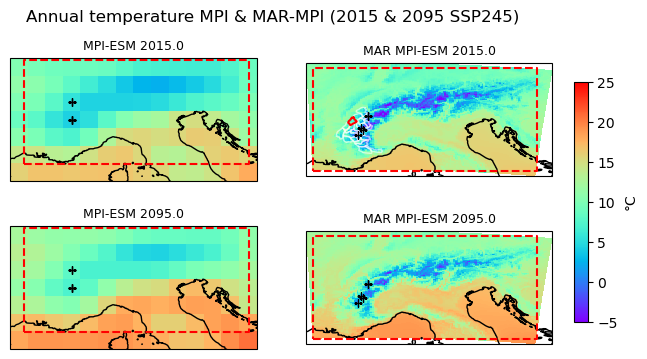

In [19]:
year1,year2=0,80
# Plot temperature pour 1er mois
fig, axs = plt.subplots(2, 2, figsize=(7, 4),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0,0].set_title(f"MPI-ESM {yearG[0]+year1}",fontsize=9)
axs[0,1].set_title(f"MAR MPI-ESM {yearM[0]+year1}",fontsize=9)
axs[1,0].set_title(f"MPI-ESM {yearG[0]+year2}",fontsize=9)
axs[1,1].set_title(f"MAR MPI-ESM {yearM[0]+year2}",fontsize=9)

# pcolormesh
m = axs[0,0].pcolormesh(
    longG, latiG, tyeaG[year1],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[0,1].pcolormesh(
    longM, latiM, tyeaM[year1],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
# pcolormesh
m = axs[1,0].pcolormesh(
    longG, latiG, tyeaG[year2],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1,1].pcolormesh(
    longM, latiM, tyeaM[year2],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

axs[0,0].add_feature(cfeature.COASTLINE)
axs[0,1].add_feature(cfeature.COASTLINE)
axs[1,0].add_feature(cfeature.COASTLINE)
axs[1,1].add_feature(cfeature.COASTLINE)
axs[0,0].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[0,1].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[1,0].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[1,1].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
#for i, ax in enumerate(axs):
#   ax.add_feature(cfeature.COASTLINE) # Does not work
   # Tracé du polygone en pointillés rouge
   #ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r')#, transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0,0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[0,1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')
    axs[1,0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1,1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')
# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('w')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[0,1].add_collection(collection)

#Massif Mont Blanc
print(patches[3])
axs[0,1].plot(patches[3].get_xy()[:, 0],patches[3].get_xy()[:, 1],color='red')
# Horizontal colorbar
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
fig.colorbar(m, cax=cbar_ax, orientation='vertical', label='°C')

fig.suptitle(f"Annual temperature MPI & MAR-MPI (2015 & 2095 {scenario})", fontsize=12)
plt.savefig(f"{path_IMG}MPI_MAR_MPI_Temp_year2015and2095_{scenario}_{yM}.png")

### 2.3 Plot annual temperature trends

In [20]:
# Seasonnal Temperature trend for GCM
slope_TG, pvalue = get_slopes_and_pvalue(tyeaG)

In [21]:
print(slope_TG.shape) # seasons, lon, lat

(7, 14)


In [22]:
# Seasonnal  Temperature trend for MAR
slope_TM, pvalue = get_slopes_and_pvalue(tyeaM)

In [23]:
print(slope_TM.shape) # seasons, lon, lat

(91, 139)


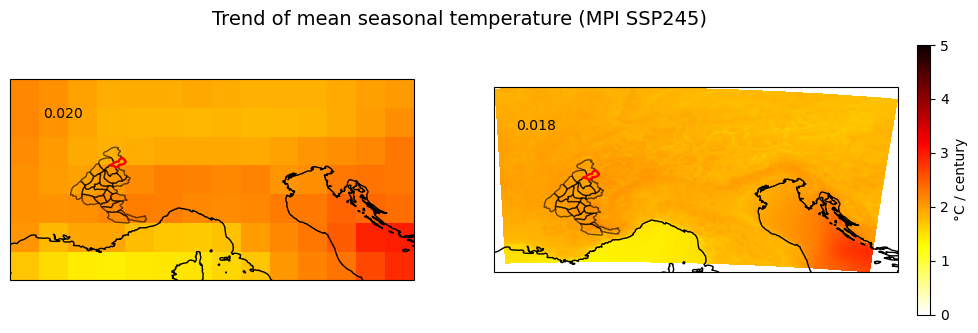

In [24]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(12, 3.5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Color scale
colo_scale = 'Oranges'#'coolwarm'
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 0., 5. #-5., 5.
#levels = np.linspace(0, 8, 65)

# Boucle principale
#for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

# ----- GCM -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
cb = ax.pcolormesh(longG, latiG, 100*slope_TG, # 100*slope_T_hist[i] ????????
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5, 47.5, f"{np.mean(slope_TG[i]):.3f}",
        ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, 100*slope_TM,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5, 47.5, f"{np.mean(slope_TM[i]):.3f}",
            ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
axs[1].set_ylabel(label, fontsize=14, rotation=90)

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('k')
    collection.set_alpha(0.6)
    axs[0].add_collection(collection)
    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection1 = PatchCollection(new_patches)
    collection1.set_color('none')
    collection1.set_edgecolor('k')
    collection1.set_alpha(0.6)
    axs[1].add_collection(collection1)

# Plot Mont Blanc in red
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='red')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='red')

fig.suptitle(f"Trend of mean seasonal temperature (MPI {scenario})", fontsize=14)

plt.savefig(f"{path_IMG}MAR_EC-EARTH_Trend_Temp_{scenario}_{yearM[0]}-{yearM[-1]}.png")

In [25]:
i=1 #MdG
xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]

# Temperature trend GCM
print(xG,yG,100*slope_TM[xG,yG])
print(xG,yG,100*slope_TM[xG+1,yG])

3 4 1.4924290659427752
3 4 1.5011417389455857


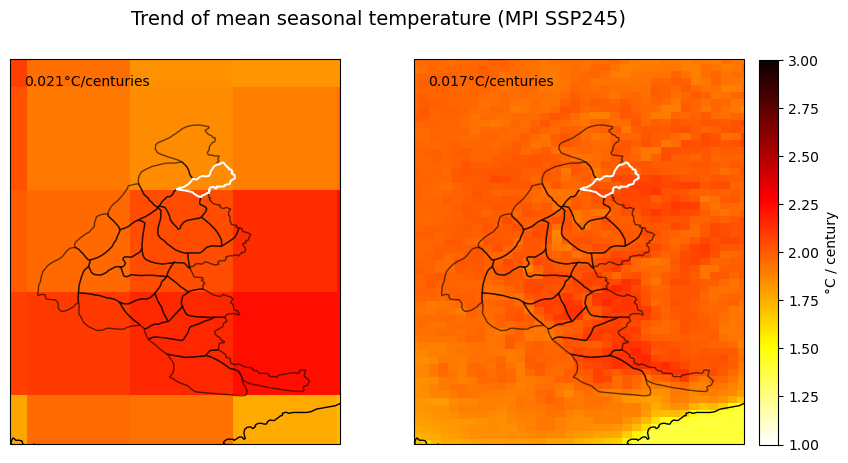

In [26]:
from copy import copy

# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(10, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Color scale
colo_scale = 'Oranges'#'coolwarm'
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 1., 3. #0., 5. #-5., 5.
#levels = np.linspace(0, 8, 65)

# Boucle principale
#for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

# ----- GCM -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
cb = ax.pcolormesh(longG, latiG, 100*slope_TG, # 100*slope_T_hist[i] ????????
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5.7, 46.8, f"{np.mean(slope_TG[i]):.3f}°C/centuries",
        ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, 100*slope_TM,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5.7, 46.8, f"{np.mean(slope_TM[i]):.3f}°C/centuries",
            ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
    
    axs[i].set_xlim(5,8)
    axs[i].set_ylim(43.5,47)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0].add_collection(collection2)
axs[1].add_collection(collection3)


# Plot Mont Blanc in red
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')

fig.suptitle("Trend of mean seasonal temperature (MPI SSP245)", fontsize=14)

plt.savefig(f"{path_IMG}MAR_EC-EARTH_Trend_Temp_SSP245_{yearM[0]}-{yearM[-1]}_Zoom.png")

In [27]:
i=1 #MdG
xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]

# Temperature trend GCM
print(xG,yG,100*slope_TG[xG,yG])
print(xG,yG,100*slope_TG[xG+1,yG])

3 4 2.1348969892171357
3 4 1.891638536577861


## 3. Compare on same grid

See https://github.com/Ian-CD/PhD/blob/master/Article_EDW/Figs_1_and_2_and_appendixB.ipynb,
Article from Ian (https://egusphere.copernicus.org/preprints/2025/egusphere-2025-6211/egusphere-2025-6211.pdf)

### 3.1 On MAR Grid

In [28]:
# To Do 
# see 3-plot-MPI-trend_seasonal_v1.ipynb

### 3.2 On GCM Grid

In [29]:
colmap = 'hot_r'
slope_TMonG = np.zeros(np.shape(slope_TG))

### At Glacioclim location 

In [30]:
# number of years
print(yearG[-1],yearG[0])
yearG[-1]-yearG[0]+1
nby=int(yearG[-1].item()-yearG[0].item()+1)

2100.0 2015.0


In [31]:
# Calculate average on a given period

#Define period for mean calculation
first_year_mean, last_year_mean = 2015, 2099 # 1960, 1990
temp = np.where( yearM == np.min(first_year_mean) ) # index of meantime first year in array of years
iy_i = temp[0].item()
temp = np.where( yearM == np.min(last_year_mean)  ) # index of meantime last...
iy_f = temp[0].item()
print(f"Index first, last years: {iy_i}, {iy_f}")

# Annual Temperature
glacioClT_yearG = np.zeros((nby,5)) # GCM
glacioClT_yearM = np.zeros((nby,5)) # MAR
# Seasonnal Temperature
glacioClT_seasG = np.zeros((nby,5,4))
glacioClT_seasM = np.zeros((nby,5,4))

# Mean Annual Temperature
glacioClTmean_yearG = np.zeros(5)
glacioClTmean_yearM = np.zeros(5)
# Mean Seasonnal Temperature
glacioClTmean_seasG = np.zeros((5,4))
glacioClTmean_seasM = np.zeros((5,4))
#glacioClTmean_seasG

Index first, last years: 0, 84


In [32]:
tmonG.shape

(86, 12, 7, 14)

In [33]:
tmonG[iy_i:iy_f,:,0,0].shape

(84, 12)

In [34]:
# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]

    # Mean Annual Temp
    glacioClTmean_yearG[i] = np.average(tmonG[iy_i:iy_f,:,xG,yG])
    glacioClTmean_yearM[i] = np.average(tmonM[iy_i:iy_f,:,xM,yM])
    # Annual Temp
    for y in range(len(yearG)):
        glacioClT_yearG[y,i] = np.average(tmonG[y,:,xG,yG])
        glacioClT_yearM[y,i] = np.average(tmonM[y,:,xM,yM])
    #print(i,xM, yM, glacioClTmean_yearG[i], glacioClTmean_yearM[i])
    #print()
    #print(i,xM, yM, glacioClT_yearG[:,i], glacioClT_yearM[:,i])
    # Season,nal Temp
    for s in range(4):
        glacioClTmean_seasG[i][s] = np.average(tsaiG[iy_i:iy_f,s,xG,yG]) 
        glacioClTmean_seasM[i][s] = np.average(tsaiM[iy_i:iy_f,s,xM,yM])
    #print(i,xM, yM, glacioClTmean_seasG[i], glacioClTmean_seasM[i])

In [35]:
print("Check the size of data Array:")
print(tmonG.shape)
print(tsaiG.shape)
print(glacioClTmean_yearM.shape)
print(glacioClTmean_seasM.shape)
print(glacioClT_seasM.shape)

Check the size of data Array:
(86, 12, 7, 14)
(86, 4, 7, 14)
(5,)
(5, 4)
(86, 5, 4)


In [36]:
# Plot 1 : massif du Mont Blanc 4 saisons
print("glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:")
print(glacioClT_yearG.shape)
print(glacioClTmean_yearG.shape)

glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:
(86, 5)
(5,)


Text(0.5, 0.98, 'Temperature for all Glacioclim Glaciers (Annual)')

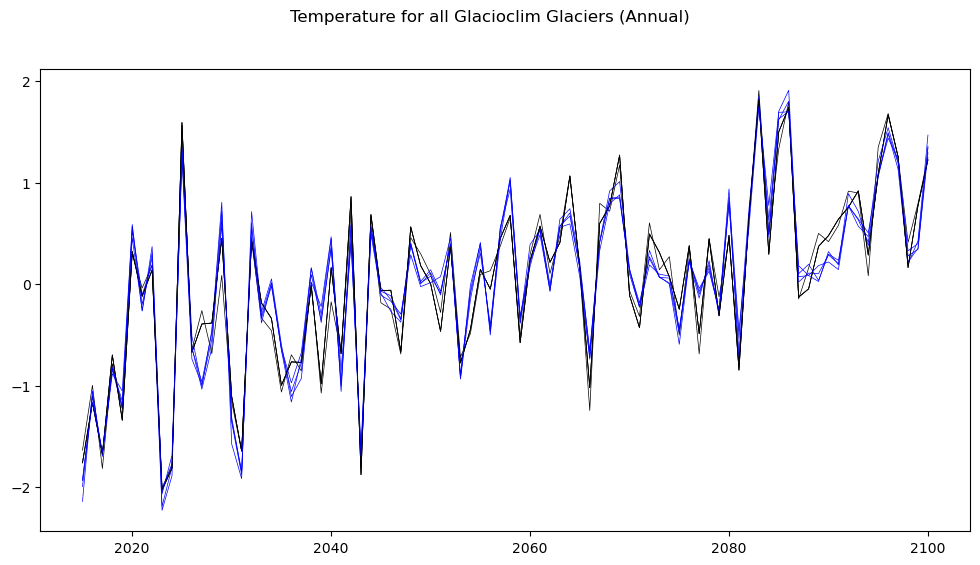

In [37]:
#Plot temperatures mensuelles pour 4 glacier
fig, ax = plt.subplots(1, figsize=(12, 6))
for i in range(4):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

    
    ax.plot(yearG,glacioClT_yearG[:,ii]-glacioClTmean_yearG[ii],'k',lw=0.5)        # T Ann
    ax.plot(yearG,glacioClT_yearM[:,ii]-glacioClTmean_yearM[ii],'b',lw=0.5)        # T Ann
fig.suptitle(f"Temperature for all Glacioclim Glaciers (Annual)", fontsize=12)

Text(0.5, 0.98, 'Temperature for Glacioclim Glaciers (Annual)')

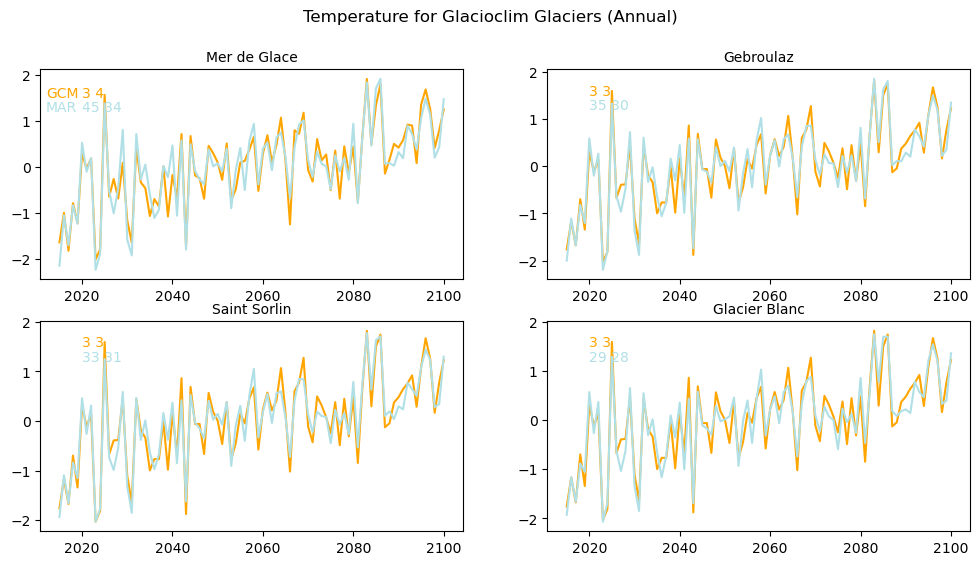

In [38]:
# Computing trends for all Glacioclim glacier (Temperature linear regression)
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()



for i, ax in enumerate(axs):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

    
    ax.plot(yearG,glacioClT_yearG[:,ii]-glacioClTmean_yearG[ii],color='orange')      # T Ann
    ax.plot(yearG,glacioClT_yearM[:,ii]-glacioClTmean_yearM[ii],color='powderblue')        # T Ann
    ax.text(2020,1.5,f'{xG} {yG}',color='orange')
    ax.text(2020,1.2,f'{xM} {yM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
    ax.set_title(glaName,fontsize=10)

axs[0].text(2012,1.5,'GCM',color='orange')
axs[0].text(2012,1.2,'MAR',color='powderblue')

fig.suptitle(f"Temperature for Glacioclim Glaciers (Annual)", fontsize=12)

In [39]:
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

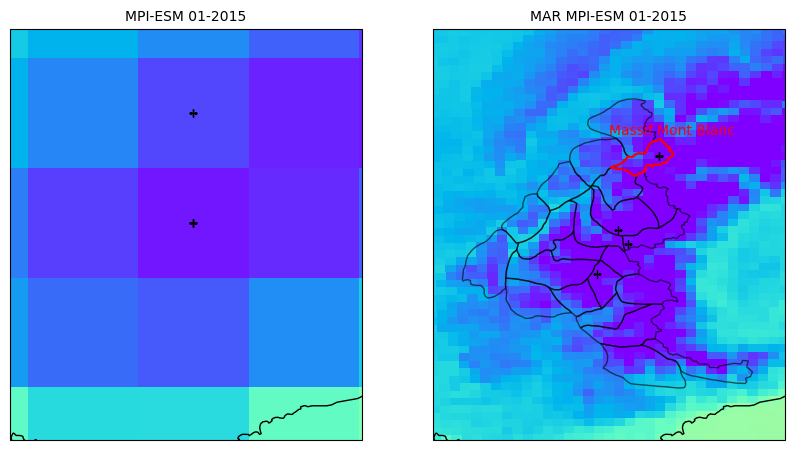

In [40]:
# Plot temperature pour 1er mois
fig, axs = plt.subplots(1, 2, figsize=(10, 6),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0].set_title("MPI-ESM 01-2015",fontsize=10)
axs[1].set_title("MAR MPI-ESM 01-2015",fontsize=10)

# pcolormesh
m = axs[0].pcolormesh(
    longG, latiG, tmonG[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1].pcolormesh(
    longM, latiM, tmonM[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

for i, ax in enumerate(axs):
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
   ax.add_feature(cfeature.COASTLINE)
#axs[1].add_feature(cfeature.COASTLINE)

# Tracé du polygone en pointillés rouge
   ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

   ax.set_xlim(5,8)
   ax.set_ylim(43.5,47)
    
# Position des glaciers (black '+')
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('k')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[1].add_collection(collection)
#    axs[0].autoscale_view()
print(collection)


# Plot Mont Blanc in red
i_ployg=2 
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='red')


axs[1].text(6.5,46.1,"Massif Mont Blanc",color="r")
fig.savefig("Temperature_Jan_2015.png")

In [41]:
### ### Create a mask for the massif 
### 1. Create the polygon
### 2. Create the 2D mask that will contain(lon,lat) at each point mask[i,j] 
### 3. Create a 2D table that will contain the (i,j) at each point table[i,j]
### 4. Fill the mask and the table
### 5. Does the points (lon,lat) are inside the poygon
###   a   Reshape Massif 2D -> 1D 
###   b   Belonging test : True if Inside poygon, False elsewhere 
###   c   Reshape 1D -> 2D
### 6. Update 2D mask and 2D table : values only for massif

# 1. Création du polygone
path = Path(patches[i_ployg].get_xy())
print(longM.shape)
# 2. 3.
Massif2D = np.zeros((91,139,2))
ij_table = np.zeros((91,139,2))
# 4.
for i in range(len(longM[:,0])):
    for j in range(len(longM[0,:])):
        #print(Massif_MB[i,j],[longM[i,j].item(),latiM[i,j].item()])
        Massif2D[i,j,:]=[longM[i,j].item(),latiM[i,j].item()]
        ij_table[i,j,:]=[i,j]

# 5. Test d'appartenance
# 5.a
print("Massif2D.shape",Massif2D.shape)
Massif1D = Massif2D.reshape(91*139,2)
print("Reshaped: Massif1D.shape",Massif1D.shape)
# 5.b
mask1D = path.contains_points(Massif1D)
# 5.c 
mask2D = mask1D.reshape(91,139)
print('1D mask.shape',mask1D.shape)
print('2D mask.shape',mask2D.shape)
#print(mask2D)

# 6. 
inside_points0 = Massif1D[mask1D] # Useless
inside_points_lola = Massif2D[mask2D]
inside_points_ij = ij_table[mask2D]

print('ip_ij',inside_points_ij.shape)
for lola in inside_points_lola :
  axs[1].plot(lola[0],lola[1],'+')
    
print(inside_points_ij)

(91, 139)
Massif2D.shape (91, 139, 2)
Reshaped: Massif1D.shape (12649, 2)
1D mask.shape (12649,)
2D mask.shape (91, 139)
ip_ij (14, 2)
[[43. 31.]
 [43. 32.]
 [44. 31.]
 [44. 32.]
 [44. 33.]
 [44. 34.]
 [45. 32.]
 [45. 33.]
 [45. 34.]
 [45. 35.]
 [46. 33.]
 [46. 34.]
 [46. 35.]
 [47. 34.]]


In [42]:
# Open Topo MAR (surface elevation)
wp_Topo_MAR = np.load(path_DIR+'numpyData/topo_MAR_SurfaceH'+'.npz')
print(wp_Topo_MAR)
topoMAR=wp_Topo_MAR['SH']

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/topo_MAR_SurfaceH.npz' with keys: SH


In [43]:
# Altitude
topoMassif = np.zeros((len(inside_points_ij)))
# Temperature trend MAR
MBT_trendM = np.zeros((len(inside_points_ij)))
print(MBT_trendM)

# Mean Annual Temperature
MBTmean_yearG = np.zeros(len(inside_points_ij))
MBTmean_yearM = np.zeros(len(inside_points_ij))

for i in range(len(inside_points_ij)):
    # Data MAR 2 matrix coordinates (LON,LAT)
    #print(inside_points1)
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    #print(xM, yM)
    
    # Fill Temp trend for each point of the massif
    MBT_trendM[i] = slope_TM[xM,yM]
    # Fill Altitude
    topoMassif[i] = topoMAR[xM,yM] 
print(MBT_trendM)
print(topoMassif)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.0204722  0.0204743  0.02027845 0.0200349  0.01989898 0.02031321
 0.01942294 0.02060235 0.02058479 0.02041758 0.02014909 0.02009076
 0.01981795 0.0196956 ]
[1862.23474121 2143.88598633 1630.87927246 1685.8560791  2951.0300293
 2657.9543457  1223.03649902 1844.0793457  2449.73510742 2748.94238281
 2001.69921875 1951.18664551 2852.06542969 1950.74597168]


In [44]:
i=1 #MdG
xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
# Temperature trend GCM
MBT_trendG = slope_TG[xG,yG]
print(MBT_trendG)

0.021348969892171357


glacier:  Mer de Glace
Argentiere 45 34 2449.735
Mer de Glace 45 34 2449.735


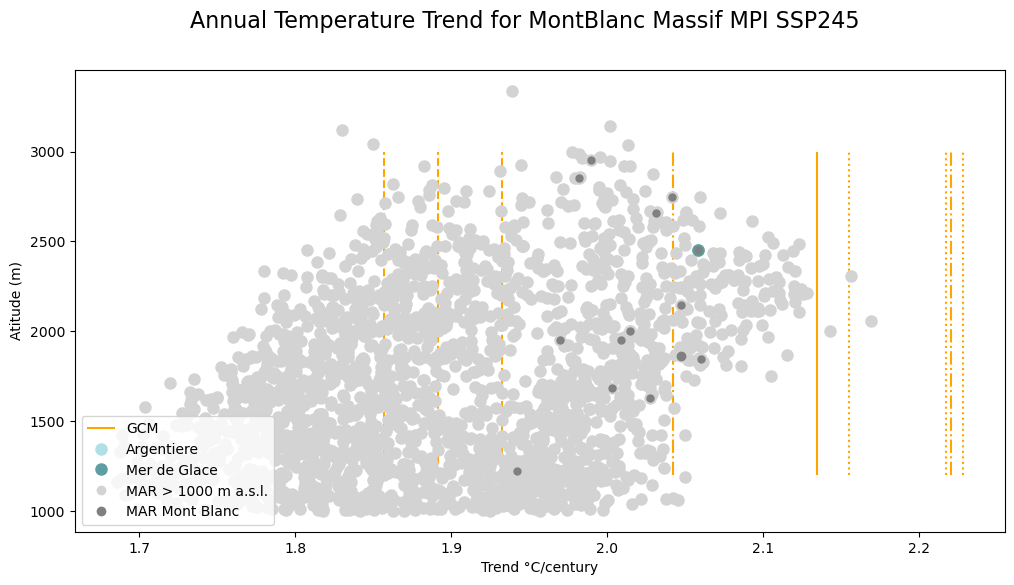

In [45]:
# Same figure with all point in a massif
#For 1 glacier : Mont Blanc
ii=1 # Mer de Glace
print ("glacier: ",glacioClXYG[ii][0])

#Plot temperatures mensuelles pour 4 glacier
fig, ax = plt.subplots(1, figsize=(12, 6))
#axs = axs.ravel()

# GCM  
ax.vlines(x=100*MBT_trendG, ymin=1200, ymax=3000,color='orange', label='GCM')

ax.vlines(x=100*slope_TG[xG-1,yG-1], ymin=1200, ymax=3000,color='orange',ls=':')
ax.vlines(x=100*slope_TG[xG-1,yG], ymin=1200, ymax=3000,color='orange',ls=':')
ax.vlines(x=100*slope_TG[xG-1,yG+1], ymin=1200, ymax=3000,color='orange',ls=':')

ax.vlines(x=100*slope_TG[xG,yG-1], ymin=1200, ymax=3000,color='orange',ls='-.')
ax.vlines(x=100*slope_TG[xG,yG+1], ymin=1200, ymax=3000,color='orange',ls='-.')

ax.vlines(x=100*slope_TG[xG+1,yG-1], ymin=1200, ymax=3000,color='orange',ls='--')
ax.vlines(x=100*slope_TG[xG+1,yG], ymin=1200, ymax=3000,color='orange',ls='--')
ax.vlines(x=100*slope_TG[xG+1,yG+1], ymin=1200, ymax=3000,color='orange',ls='--')


# MAR

# French Alps
for i in range(20,80):
    for j in range(10,110):
        if topoMAR[i, j] >=1000:
            ax.plot(100*slope_TM[i,j],topoMAR[i, j],'o',ms=8,color='lightgrey')
# Arg & MdG
ii=0
nameM, xM, yM = glacioClXYM[ii][0], glacioClXYM[ii][1],glacioClXYM[ii][2]
print(nameM, xM, yM,topoMAR[xM, yM])
ax.plot(100*slope_TM[xM,yM],topoMAR[xM, yM],'o',ms=8,color='powderblue',label=nameM)
ii=1
nameM, xM, yM = glacioClXYM[ii][0], glacioClXYM[ii][1],glacioClXYM[ii][2]
print(nameM, xM, yM,topoMAR[xM, yM])
ax.plot(100*slope_TM[xM,yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM)

#Mont Blanc
ax.plot(100*MBT_trendM[0],topoMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
ax.plot(100*MBT_trendM[0],topoMassif[0],'o',color='grey',label='MAR Mont Blanc')
# Loop on all the point of the massif
for pt in range(len(inside_points_ij)): 
    ax.plot(100*MBT_trendM[pt],topoMassif[pt],'o',color='grey',ms=5) # -MBTmean_yearM[pt]
    

ax.set_xlabel('Trend °C/century')
ax.set_ylabel('Atitude (m)')
ax.legend(loc='lower left')

fig.suptitle(f"Annual Temperature Trend for MontBlanc Massif MPI {scenario}", fontsize=16)
fig.savefig(f"{path_IMG}AnnualTemperatureTrendforMontBlancMassif_MPI_{scenario}.png")